In [5]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [7]:
model = YOLO("../notebooks/runs/detect/train/weights/best.pt")

In [8]:
video_path = "../videos/cricket_ball_demo.mp4"
cap = cv2.VideoCapture(video_path)

In [9]:
ball_positions = []

last_position = None
MAX_DISTANCE = 60   # max allowed movement between frames

frame_id = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # run detection
    results = model(frame, conf=0.35)[0]

    if results.boxes is not None and len(results.boxes) > 0:

        boxes = results.boxes.xyxy.cpu().numpy()

        # choose best detection
        x1, y1, x2, y2 = boxes[0]

        cx = int((x1 + x2) / 2)
        cy = int((y1 + y2) / 2)

        if last_position is None:
            ball_positions.append((frame_id, cx, cy))
            last_position = (cx, cy)

        else:
            distance = np.sqrt(
                (cx - last_position[0])**2 +
                (cy - last_position[1])**2
            )

            # accept only realistic motion
            if distance < MAX_DISTANCE:
                ball_positions.append((frame_id, cx, cy))
                last_position = (cx, cy)

    frame_id += 1

cap.release()

print("Valid trajectory points:", len(ball_positions))


0: 640x384 (no detections), 65.1ms
Speed: 2.0ms preprocess, 65.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 (no detections), 48.8ms
Speed: 1.1ms preprocess, 48.8ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 (no detections), 44.9ms
Speed: 1.6ms preprocess, 44.9ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 (no detections), 46.3ms
Speed: 1.1ms preprocess, 46.3ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 (no detections), 46.5ms
Speed: 1.3ms preprocess, 46.5ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 (no detections), 44.4ms
Speed: 0.9ms preprocess, 44.4ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 (no detections), 45.2ms
Speed: 0.9ms preprocess, 45.2ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 (no detections), 43.2ms
Speed: 1.3ms preprocess, 43.2ms i

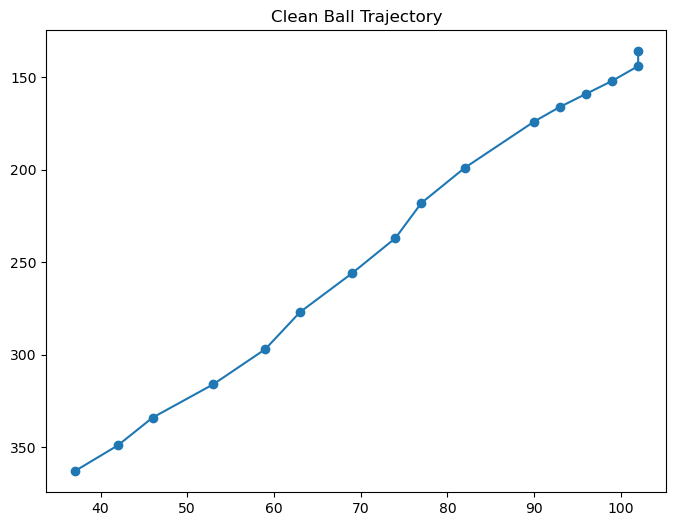

In [10]:
x = [p[1] for p in ball_positions]
y = [p[2] for p in ball_positions]

plt.figure(figsize=(8,6))
plt.plot(x, y, marker='o')
plt.gca().invert_yaxis()
plt.title("Clean Ball Trajectory")
plt.show()

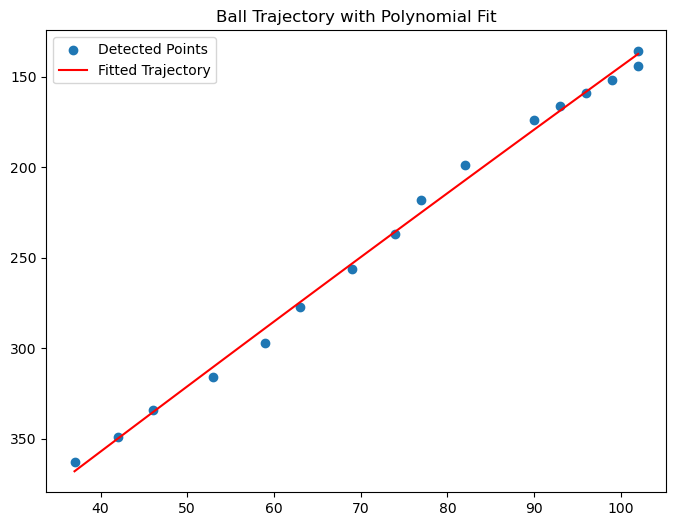

In [11]:
import numpy as np

x = np.array([p[1] for p in ball_positions])
y = np.array([p[2] for p in ball_positions])

# fit quadratic curve
coeff = np.polyfit(x, y, 2)

poly = np.poly1d(coeff)

x_smooth = np.linspace(min(x), max(x), 100)
y_smooth = poly(x_smooth)

plt.figure(figsize=(8,6))
plt.scatter(x, y, label="Detected Points")
plt.plot(x_smooth, y_smooth, color="red", label="Fitted Trajectory")
plt.gca().invert_yaxis()
plt.legend()
plt.title("Ball Trajectory with Polynomial Fit")
plt.show()

In [15]:
y = np.array([p[2] for p in ball_positions])

dy = np.diff(y)

bounce_index = None

for i in range(1, len(dy)):
    if dy[i-1] < 0 and dy[i] > 0:
        bounce_index = i
        break

print("Bounce index:", bounce_index)

Bounce index: None
